# AVISO eddy velocity overlay

Plot native AVISO absolute geostrophic velocity and overlay the processed ESP/DOPPIO eddy centres, IDs, polarity, and fitted maximum-tangential-velocity contours.

In [1]:
from pathlib import Path
import sys

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
for source in (PROJECT_ROOT / "src", PROJECT_ROOT.parent / "seacofs_eddy_dataset_modular" / "src"):
    if str(source) not in sys.path:
        sys.path.insert(0, str(source))

from aviso_eddy_dataset.grid import build_grid, native_velocity

## Load the processed dataset

In [2]:
DATA_ROOT = Path("/srv/scratch/z5502183/AVISO_0.125")
DATA_PATH = Path("/srv/scratch/z5297792/aviso_eddy_dataset/processed/eddy_dataset_processed.parquet")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Processed dataset not found: {DATA_PATH}")

df = pd.read_parquet(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Day", "Eddy"]).reset_index(drop=True)
print(f"Loaded {len(df):,} eddy-day rows ({df.Eddy.nunique():,} eddies).")
print(f"Coverage: {df.Date.min():%Y-%m-%d} to {df.Date.max():%Y-%m-%d}")
df.head()

Loaded 453,309 eddy-day rows (8,979 eddies).
Coverage: 1994-01-02 to 2019-02-28


,Eddy,Day,Date,Cyc,lon,lat,ic,jc,xc,yc,...,Omega,q11,q12,q22,Rc,psi0,AR,R,Age,source_file
0,1,16072,1994-01-02,AE,149.388784,-41.813765,35,9,397.941074,124.679076,...,3.569027e-06,1.776830,-0.465120,0.687729,125.323701,-28.027626,1.942958,75.590039,47,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...
1,2,16072,1994-01-02,AE,162.476893,-41.521308,139,11,1601.814040,157.127283,...,7.679156e-07,0.583692,-0.236117,1.824122,85.887934,-4.174331,1.859224,50.573180,27,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...
2,3,16072,1994-01-02,AE,157.200693,-41.080408,97,15,1116.497616,206.045383,...,4.908212e-06,1.138781,0.165381,0.902372,73.533383,-13.269739,1.223702,44.424033,63,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...
3,4,16072,1994-01-02,AE,159.600579,-40.535124,116,19,1337.244445,266.544988,...,2.871434e-06,0.940827,0.090857,1.071695,80.253842,-9.246993,1.118214,53.716394,79,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...
4,5,16072,1994-01-02,CE,157.939832,-40.395254,103,20,1184.485264,282.063693,...,-5.737237e-06,0.991350,-0.030773,1.009742,52.427181,7.884711,1.032633,37.596495,48,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...


## Plotting function

Pass an integer pipeline `Day` or a date such as `"1994-06-01"`. The source NetCDF is taken from `source_file`, with an annual-file fallback.

In [25]:
def _resolve_day(day_or_date, df_data):
    if isinstance(day_or_date, (int, np.integer)):
        day = int(day_or_date)
        dates = df_data.loc[df_data.Day.eq(day), "Date"]
        if dates.empty:
            raise KeyError(f"Day {day} is absent from the processed dataset.")
        date = pd.Timestamp(dates.iloc[0]).normalize()
    else:
        date = pd.Timestamp(day_or_date).normalize()
        days = df_data.loc[df_data.Date.dt.normalize().eq(date), "Day"]
        if days.empty:
            raise KeyError(f"Date {date:%Y-%m-%d} is absent from the processed dataset.")
        day = int(days.iloc[0])
    return day, date

def _resolve_source_file(df_day, date):
    if "source_file" in df_day:
        for value in df_day.source_file.dropna().unique():
            path = Path(str(value)).expanduser()
            if path.exists():
                return path
    fallback = DATA_ROOT / f"AVISO_0.125_EAC_{date.year}.nc"
    if fallback.exists():
        return fallback
    raise FileNotFoundError(f"Could not find the AVISO source for {date:%Y-%m-%d}.")

def _time_index(dataset, date):
    dates = pd.DatetimeIndex(dataset.time.values).normalize()
    matches = np.flatnonzero(dates == pd.Timestamp(date).normalize())
    if matches.size != 1:
        raise KeyError(f"Expected one {date:%Y-%m-%d} time; found {matches.size}.")
    return int(matches[0])

def day_plot(day_or_date, df_data=df, *, num_label=True, show_quiver=True, quiver_step=3, speed_vmax=None, figsize=(9, 10), width=0.0015):
    """Overlay processed eddies on native, unrotated AVISO ugos/vgos."""
    day, date = _resolve_day(day_or_date, df_data)
    df_day = df_data.loc[df_data.Day.eq(day)].copy()
    source_file = _resolve_source_file(df_day, date)

    with xr.open_dataset(source_file, decode_times=True) as dataset:
        t = _time_index(dataset, date)
        grid = build_grid(dataset.longitude.values, dataset.latitude.values)
        u = native_velocity(dataset.ugos.isel(time=t), grid)
        v = native_velocity(dataset.vgos.isel(time=t), grid)

    speed = np.hypot(u, v)
    speed_vmax = float(np.nanpercentile(speed, 99)) if speed_vmax is None else speed_vmax
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    image = ax.pcolormesh(grid.X_grid, grid.Y_grid, speed, shading="auto", vmin=0, vmax=speed_vmax, cmap="Blues_r")
    fig.colorbar(image, ax=ax, label=r"Absolute geostrophic speed (m s$^{-1}$)")

    if show_quiver:
        step = max(1, int(quiver_step))
        ax.quiver(grid.X_grid[::step, ::step], grid.Y_grid[::step, ::step], u[::step, ::step], v[::step, ::step], color="0.2", alpha=0.55, pivot="mid", width=width)

    colours = {"AE": "red", "CE": "cyan"}
    for row in df_day.itertuples(index=False):
        colour = colours.get(row.Cyc, "white")
        ax.scatter(row.xc, row.yc, color=colour, edgecolor="black", linewidth=0.8, s=20, zorder=10)
        if np.all(np.isfinite([row.q11, row.q12, row.q22, row.Rc])):
            Q = np.array([[row.q11, row.q12], [row.q12, row.q22]], dtype=float)
            dx, dy = grid.X_grid - row.xc, grid.Y_grid - row.yc
            rho2 = Q[0, 0] * dx**2 + 2 * Q[0, 1] * dx * dy + Q[1, 1] * dy**2
            ax.contour(grid.X_grid, grid.Y_grid, rho2, levels=[row.Rc**2 / 2], colors=[colour], linewidths=1.5, zorder=9)
        if num_label:
            ax.annotate(str(int(row.Eddy)), (row.xc, row.yc), textcoords="offset points", xytext=(3, 3), fontsize=8, color="white", weight="bold", path_effects=[pe.withStroke(linewidth=2, foreground="black")], zorder=11)

    lon_field = np.broadcast_to(grid.longitude[:, None], grid.X_grid.shape)
    lat_field = np.broadcast_to(grid.latitude[None, :], grid.Y_grid.shape)
    lon_levels = np.arange(np.ceil(grid.longitude.min() / 5) * 5, grid.longitude.max(), 5)
    lat_levels = np.arange(np.ceil(grid.latitude.min() / 5) * 5, grid.latitude.max(), 5)
    if lat_levels.size:
        c = ax.contour(grid.X_grid, grid.Y_grid, lat_field, levels=lat_levels, colors="black", linewidths=0.5, alpha=0.7)
        ax.clabel(c, fmt=lambda value: f"{abs(value):.0f}°S", fontsize=8)
    if lon_levels.size:
        c = ax.contour(grid.X_grid, grid.Y_grid, lon_field, levels=lon_levels, colors="black", linewidths=0.5, alpha=0.7)
        ax.clabel(c, fmt=lambda value: f"{value:.0f}°E", fontsize=8)

    ae_count, ce_count = int(df_day.Cyc.eq("AE").sum()), int(df_day.Cyc.eq("CE").sum())
    ax.set(title=f"AVISO eddies | Day {day} | {date:%Y-%m-%d} | AE={ae_count}, CE={ce_count}", xlabel="x (km)", ylabel="y (km)", xlim=(grid.x_grid.min(), grid.x_grid.max()), ylim=(grid.y_grid.min(), grid.y_grid.max()), aspect="equal")
    print(f"Source: {source_file}")
    print(f"Plotted {len(df_day)} eddies: {ae_count} AEs and {ce_count} CEs")
    return fig, ax, df_day

## Plot a day

The default selects the day containing the most processed eddies. Replace `DAY` with another integer or date string.

In [7]:
df.Day.unique()

array([16072, 16073, 16074, ..., 25258, 25259, 25260], shape=(9189,))

Source: /srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_EAC_1999.nc
Plotted 41 eddies: 16 AEs and 25 CEs


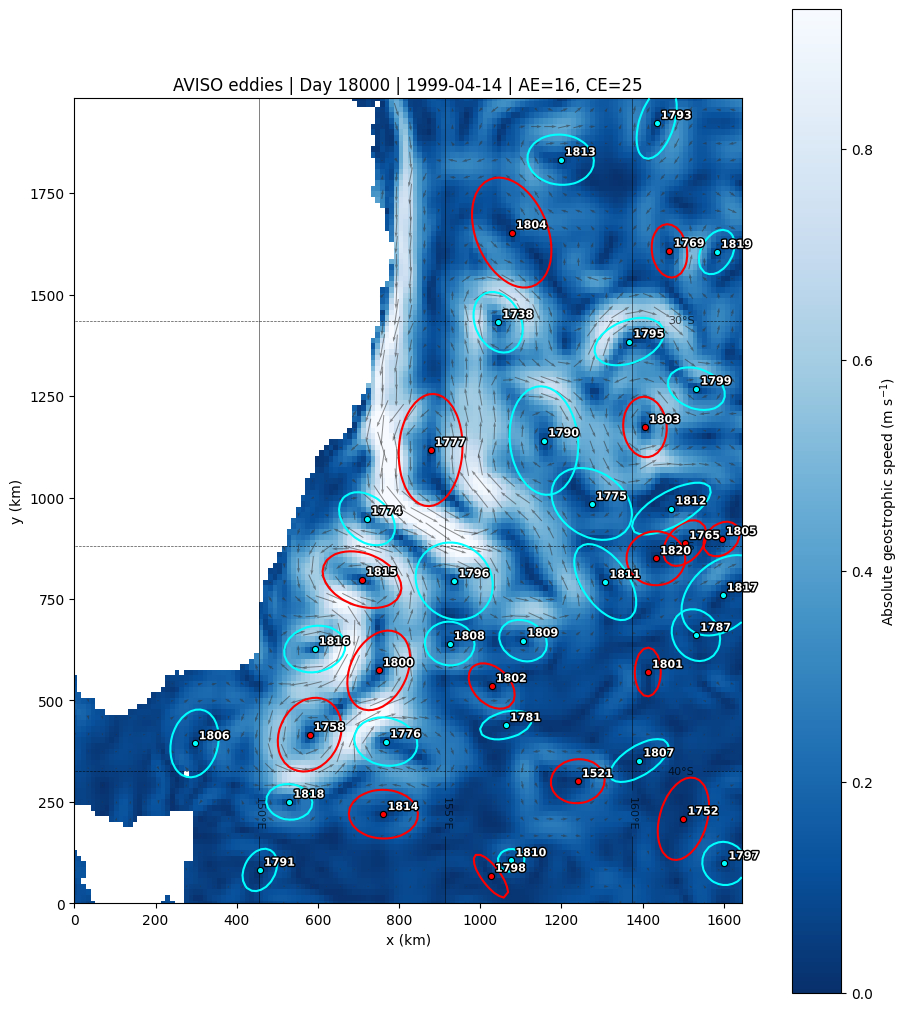

In [34]:
# DAY = int(df.groupby("Day").size().idxmax())
DAY = 18000

fig, ax, df_day = day_plot(DAY, num_label=True, show_quiver=True, quiver_step=3, width=0.0015)

## Inspect plotted eddies

In [5]:
df_day[["Eddy", "Day", "Date", "Cyc", "lon", "lat", "R", "Rc", "Omega"]]

,Eddy,Day,Date,Cyc,lon,lat,R,Rc,Omega
152192,2846,19259,2002-09-24,AE,161.072253,-42.019306,34.755016,60.413631,0.000004
152193,2887,19259,2002-09-24,CE,151.361321,-42.631150,55.828274,79.469041,-0.000012
152194,2890,19259,2002-09-24,AE,151.679977,-41.322237,62.237476,85.430518,0.000013
152195,2932,19259,2002-09-24,CE,160.069904,-28.243394,94.048547,133.121478,-0.000004
152196,2936,19259,2002-09-24,AE,151.509990,-38.043054,91.815063,119.951244,0.000014
...,...,...,...,...,...,...,...,...,...
152254,3082,19259,2002-09-24,CE,162.794042,-37.590013,43.359603,56.556594,-0.000004
152255,3083,19259,2002-09-24,AE,158.085452,-29.249098,69.350621,96.915777,0.000010
152256,3084,19259,2002-09-24,CE,148.035116,-39.360335,45.721978,73.709963,-0.000002
152257,3085,19259,2002-09-24,CE,158.927081,-38.182492,58.769721,90.893553,-0.000003


## Optional sequence

In [6]:
# for date in ["1994-03-01", "1994-06-01", "1994-09-01"]:
#     day_plot(date, num_label=False, quiver_step=4)
#     plt.show()